# 5. Extending telescope-sim with custom components

Every pipeline stage in `telescope-sim` — apertures, correctors, coronagraphs, focal planes, output taps, post-processors — is a **registered** implementation of a small ABC. To add a new component, subclass the appropriate ABC, decorate the class with `@register("<kind>", "<name>")`, and import the module so the decorator runs. The YAML/Python config then references it by name.

This tutorial walks through two concrete examples that close feature gaps without needing to modify the package itself:

- **Part 1** — a custom `XineticsDM` corrector that auto-fits the
  surface of a stock `segmented_ptt` corrector (the legacy
  `aprox_ptt_with_dm` workflow).
- **Part 2** — a custom `PowScale` post-processor for dynamic-range
  compression of PSF images (the legacy `extra_processing.pow_scale`
  field).

Both follow the same recipe: write a class, decorate, reference by name. The same pattern extends to all six pluggable kinds.

## Part 1 — Custom Corrector: a Xinetics DM

HCIPy ships `make_xinetics_influence_functions` for a regular Xinetics actuator grid. The `Corrector` ABC needs `apply`, `set_actuators`, `n_actuators`, `actuators`, and — for fit-role usage — `fit_surface`. Optionally implement `_bind_pupil_grid` to defer HCIPy DM construction until the loader has a pupil grid (so the class can be instantiated before sim build).

The structure below mirrors the package's existing `ZernikeCorrector` almost line-for-line: same lstsq-on-aperture-masked-pixels fit, same OPD-vs-surface convention (`fit_surface` returns *matching* caller-facing actuator values; the pipeline negates at the apply site for `wavefront_role="fit"`).

In [1]:
import hcipy
import numpy as np
import matplotlib.pyplot as plt

from telescope_sim.abc import Corrector
from telescope_sim.registry import register


@register('corrector', 'xinetics_dm')
class XineticsDM(Corrector):
    '''Xinetics-style DM with lstsq fit_surface, for fit-role usage.'''

    def __init__(
        self,
        num_actuators_across_pupil,
        actuator_spacing,
        *,
        actuate_scale=1.0,
        name='xinetics_dm',
        wavefront_role='actuate',
        target_strategy='none',
        fit_source=None,
        target=False,
    ):
        self.name = name
        self.num_actuators_across_pupil = int(num_actuators_across_pupil)
        self.actuator_spacing = float(actuator_spacing)
        self.actuate_scale = float(actuate_scale)
        self.wavefront_role = wavefront_role
        self.target_strategy = target_strategy
        self.fit_source = fit_source
        self.target = target
        self._dm = None
        self._basis_matrix = None
        self._aperture_mask = None

    def _bind_pupil_grid(self, pupil_grid, aperture_field):
        basis = hcipy.make_xinetics_influence_functions(
            pupil_grid, self.num_actuators_across_pupil, self.actuator_spacing
        )
        self._dm = hcipy.DeformableMirror(basis)
        self._basis_matrix = np.column_stack(
            [np.asarray(m, dtype=float).ravel() for m in basis]
        )
        self._aperture_mask = np.asarray(aperture_field, dtype=float).ravel() > 0

    def apply(self, wf):
        return self._dm(wf)

    def set_actuators(self, values):
        arr = np.asarray(values, dtype=float).reshape(-1)
        self._dm.actuators = arr * self.actuate_scale

    def flatten(self):
        if self._dm is not None:
            self._dm.actuators = np.zeros(self.n_actuators)

    def fit_surface(self, phase):
        phase = np.asarray(phase, dtype=float).ravel()
        phase = phase - phase[self._aperture_mask].mean()
        B = self._basis_matrix[self._aperture_mask]
        rhs = phase[self._aperture_mask]
        amps, _, _, _ = np.linalg.lstsq(B, rhs, rcond=None)
        return amps / (2.0 * self.actuate_scale)

    @property
    def n_actuators(self):
        return self.num_actuators_across_pupil ** 2

    @property
    def actuators(self):
        if self._dm is None:
            return np.zeros(self.n_actuators)
        return np.asarray(self._dm.actuators) / self.actuate_scale

print('xinetics_dm registered')


xinetics_dm registered


Build two sims sharing the same single-segment circular aperture and a stock `segmented_ptt` corrector. Sim A has only the PTT corrector; Sim B adds the new `xinetics_dm` downstream as a fit-role corrector with `fit_source="cumulative_phase_pre_self"`, so it auto-fits (and cancels) whatever the PTT corrector imposed.

`target_strategy="residual_fit_only"` makes `out["actuations"]["xinetics_dm"]` report the actuator values needed — the legacy `aprox_ptt_with_dm` output.

In [2]:
from telescope_sim.config.schema import SimConfig
from telescope_sim.config.loader import build

base_cfg = {
    'pupil': {'resolution': 256, 'extent': 1.05},
    'aperture': {
        'type': 'segmented_circular',
        'segment_diameter': 1.0,
        'layout': 'custom',
        'positions': [[0.0, 0.0]],
        'supersample': 16,
    },
    'correctors': {
        'segments': {
            'type': 'segmented_ptt',
            'piston_scale': 1.0e-6, 'tip_tilt_scale': 1.0e-6,
            'wavefront_role': 'impose',
            'target_strategy': 'actuators', 'target': True,
        },
    },
    'corrector_chain': ['segments'],
    'focal_planes': {
        'filter1': {
            'type': 'angular', 'central_lam': 1.0e-6,
            'focal_extent': 2.0, 'focal_res': 128,
            'fractional_bandwidth': 0.0, 'num_samples': 1,
        },
    },
    'outputs': {
        'psf': {
            'tap': {'type': 'intensity', 'focal_planes': ['filter1']},
            'post_processing': [{'type': 'max_intensity_norm'}],
        },
    },
}
ptt_only_sim = build(SimConfig.model_validate(base_cfg))

# Sim B adds xinetics_dm downstream as a fit-role corrector.
ptt_plus_dm_cfg = {**base_cfg}
ptt_plus_dm_cfg['correctors'] = {
    **base_cfg['correctors'],
    'xinetics_dm': {
        'type': 'xinetics_dm',
        'num_actuators_across_pupil': 12,
        'actuator_spacing': 1.0 / 12,
        'actuate_scale': 1.0e-6,
        'wavefront_role': 'fit',
        'fit_source': 'cumulative_phase_pre_self',
        'target_strategy': 'residual_fit_only',
        'target': True,
    },
}
ptt_plus_dm_cfg['corrector_chain'] = ['segments', 'xinetics_dm']
ptt_plus_dm_sim = build(SimConfig.model_validate(ptt_plus_dm_cfg))
print('sim A correctors:', list(ptt_only_sim.correctors))
print('sim B correctors:', list(ptt_plus_dm_sim.correctors))


sim A correctors: ['segments']
sim B correctors: ['segments', 'xinetics_dm']


Push a non-trivial PTT on the segmented mirror and sample both sims. The fit-role DM in Sim B should auto-cancel the imposed PTT.

In [3]:
ptt = np.array([[0.2, 1.5, 0.7]])  # piston=0.2um, tip=1.5um-rad, tilt=0.7um-rad
actuations = {'segments': ptt}

out_ptt = ptt_only_sim.sample(actuations=actuations, meas_strehl=True)
out_corr = ptt_plus_dm_sim.sample(actuations=actuations, meas_strehl=True)
print(f"Strehl, PTT only:  {out_ptt['strehls']['filter1']:.3f}")
print(f"Strehl, PTT + DM:  {out_corr['strehls']['filter1']:.3f}")
print('xinetics_dm fit actuator vector shape:',
      out_corr['actuations']['xinetics_dm'].shape)


Strehl, PTT only:  0.000
Strehl, PTT + DM:  0.869
xinetics_dm fit actuator vector shape: (144,)


Visualize the pupil-plane OPDs: the PTT-imposed OPD, the DM's matching fit, and the residual after fit. The fit-role DM applies `-matching_amps` to cancel; the residual is what's left.

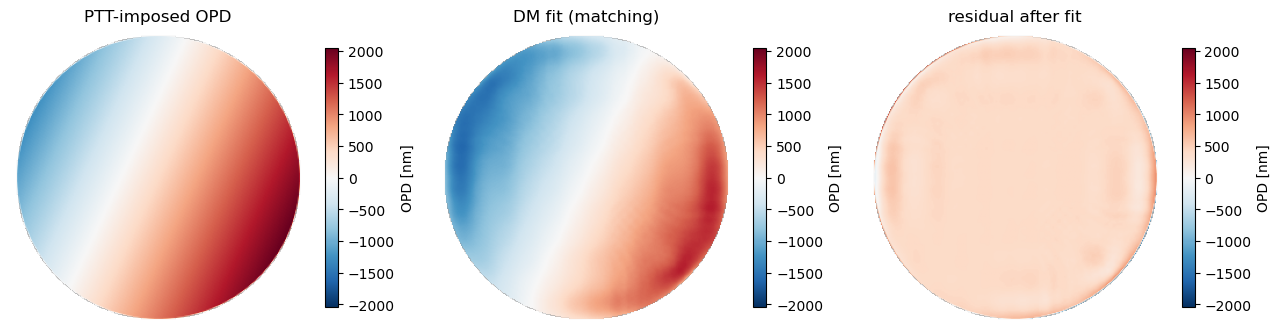

PTT OPD RMS:      821.9 nm
residual OPD RMS: 97.3 nm


In [4]:
# Reach into the sim's internals to pull the actual surfaces.
# (Tutorial code can do this; library code shouldn't.)
segments_corr = ptt_plus_dm_sim.correctors['segments']
xinetics_corr = ptt_plus_dm_sim.correctors['xinetics_dm']
shape2d = (256, 256)

ptt_opd = 2.0 * np.asarray(segments_corr._sm.surface).reshape(shape2d)
# After fit-role apply: dm.surface = -matching_surface; DM OPD = -matching_opd.
# Flip sign for the 'reconstruction' display so it visibly matches PTT.
dm_opd_match = -2.0 * np.asarray(xinetics_corr._dm.surface).reshape(shape2d)
residual_opd = ptt_opd - dm_opd_match
aperture_mask = (
    np.asarray(ptt_plus_dm_sim.aperture.field).reshape(shape2d) > 0
)
# Common color scale for the OPD panels (in nm).
vmax = 1e9 * np.max(np.abs(ptt_opd[aperture_mask]))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, opd, title in zip(
    axes,
    [ptt_opd, dm_opd_match, residual_opd],
    ['PTT-imposed OPD', 'DM fit (matching)', 'residual after fit'],
):
    masked = np.where(aperture_mask, 1e9 * opd, np.nan)
    im = ax.imshow(masked, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.7, label='OPD [nm]')
plt.tight_layout()
plt.show()

rms_ptt = 1e9 * np.std(ptt_opd[aperture_mask])
rms_res = 1e9 * np.std(residual_opd[aperture_mask])
print(f'PTT OPD RMS:      {rms_ptt:.1f} nm')
print(f'residual OPD RMS: {rms_res:.1f} nm')


And the focal-plane PSFs side-by-side. (Sharing one LogNorm across both panels keeps the colorbars directly comparable.)

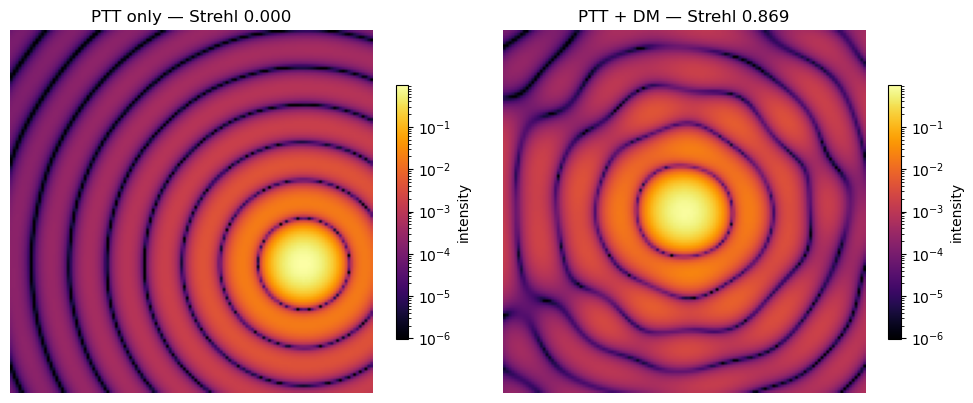

In [5]:
from matplotlib.colors import LogNorm

psf_ptt = out_ptt['images']['psf'][..., 0]
psf_corr = out_corr['images']['psf'][..., 0]
vmax = float(max(psf_ptt.max(), psf_corr.max()))
norm = LogNorm(vmin=vmax * 1e-6, vmax=vmax)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, img, title in [
    (axes[0], psf_ptt,
     f"PTT only — Strehl {out_ptt['strehls']['filter1']:.3f}"),
    (axes[1], psf_corr,
     f"PTT + DM — Strehl {out_corr['strehls']['filter1']:.3f}"),
]:
    im = ax.imshow(img, norm=norm, cmap='inferno')
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.7, label='intensity')
plt.tight_layout()
plt.show()


## Part 2 — Custom PostProcessor: `PowScale`

Post-processors are simpler: one method (`__call__`) on the `PostProcessor` ABC. The processor receives the current image and a `PipelineContext` carrying reference values and per-sample overrides. We use the overrides channel here so the same registered class works with either a YAML-default `power` or a per-sample `power` override.

This re-creates the legacy `extra_processing.pow_scale` field — useful for compressing the dynamic range of training data (square-root or fourth-root of the PSF surfaces both peak and wings together).

In [6]:
from telescope_sim.abc import PostProcessor


@register('post_processor', 'pow_scale')
class PowScale(PostProcessor):
    name = 'pow_scale'

    def __init__(self, power=1.0):
        self.power = float(power)

    def __call__(self, image, context):
        # Per-sample override beats YAML default. Clamp to avoid
        # NaNs from non-integer powers of tiny-negative noise pixels.
        power = float(context.overrides.get('power', self.power))
        return np.clip(image, 0.0, None) ** power

print('pow_scale registered')


pow_scale registered


Build a sim with `pow_scale` (power=0.5 from YAML) layered after `max_intensity_norm`. Then sweep `power` per-sample via `output_overrides`.

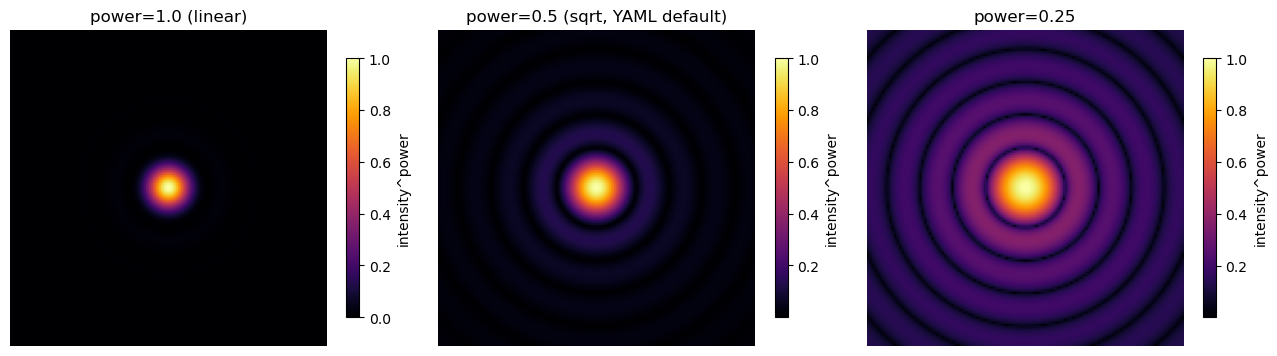

In [7]:
pow_cfg = {**base_cfg}
pow_cfg['outputs'] = {
    'psf': {
        'tap': {'type': 'intensity', 'focal_planes': ['filter1']},
        'post_processing': [
            {'type': 'max_intensity_norm'},
            {'type': 'pow_scale', 'power': 0.5},
        ],
    },
}
pow_sim = build(SimConfig.model_validate(pow_cfg))

# At-rest PSF — the centered Airy disk shows pow_scale's dynamic-range
# compression most clearly.
out_lin = pow_sim.sample(output_overrides={'psf': {'power': 1.0}})
out_sqrt = pow_sim.sample()  # YAML default power=0.5
out_qrt = pow_sim.sample(output_overrides={'psf': {'power': 0.25}})

# Linear colormaps here — pow_scale itself is the dynamic-range
# compression, so log on top would hide what we're showing.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, out_i, label in zip(
    axes,
    [out_lin, out_sqrt, out_qrt],
    ['power=1.0 (linear)', 'power=0.5 (sqrt, YAML default)', 'power=0.25'],
):
    im = ax.imshow(out_i['images']['psf'][..., 0], cmap='inferno')
    ax.set_title(label)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.7, label='intensity^power')
plt.tight_layout()
plt.show()


## Recap

Both examples follow the same recipe:

1. Subclass the right ABC (`Corrector`, `PostProcessor`, …).
2. Implement the required methods.
3. Decorate with `@register("<kind>", "<name>")`.
4. Reference by name in YAML or a Python config dict.

The same pattern extends to **all six** pluggable component kinds: `aperture`, `corrector`, `coronagraph`, `focal_plane`, `output_tap`, `post_processor`. As long as the class is imported before the loader runs (the `@register` decorator has to execute), the YAML loader picks it up automatically — no fork of `telescope-sim` required.